# 获取数据集

In [ ]:
%reset -f

In [ ]:
!pip install objaverse --upgrade --quiet

import objaverse
objaverse.__version__

'0.1.7'

In [ ]:
annotations = objaverse.load_annotations()

100%|██████████| 160/160 [01:10<00:00,  2.26it/s]


In [ ]:
chair_uids = []

for uid, anno in annotations.items():
    name = str(anno.get("name", "")).lower()
    tags = " ".join([
        str(t.get("name", "")).lower()
        for t in anno.get("tags", [])
    ])
    description = str(anno.get("description", ""))

    # 筛选逻辑：名称/标签包含 chair，且说明内容长度大于 10 字符
    text = name + " " + tags
    if "chair" in text and len(description) > 10:
        chair_uids.append(uid)

print("找到说明丰富的 chair 模型数量:", len(chair_uids))
print(chair_uids[:10])

找到说明丰富的 chair 模型数量: 3686
['9a1207987eef4dcba42c31b1fd60009e', 'd5c97f124faa4e91acc045db07138f94', '2c55138f228048f4b77b70c1d93ea9c9', '0448e3a5b33c419f97cc891442b99158', 'ee2a9294b02f47ab9f03d189c1dddcc2', '2e5eed6cd61e4838831ac9f15455e498', '17b2119223214b969c4dbe178fd80015', 'a2f5d02d7591408f9188512e7b3ae307', 'ef90ce3a7d2a47e99eeef1e94b789e68', '033baf0ff0a94657841230587ad3e67b']


In [ ]:
import gc

# 检查变量是否存在并删除
if 'annotations' in locals():
    del annotations
    print("已删除 annotations 变量。")

# 强制进行垃圾回收以释放内存
gc.collect()
print("内存回收完成。")

已删除 annotations 变量。
内存回收完成。


In [ ]:
import objaverse
import os
import shutil

# 选定前 500 个筛选出的 UID
selected_uids = chair_uids[:500]

# 使用 objaverse 官方下载器，它会自动处理分片路径 (glbs/xxx-xxx/uid.glb)
# processes=4 表示开启 4 线程并行下载
# 注意：load_objects 会返回一个 dict，key 是 uid，value 是本地文件路径
processes = 4
downloaded_objects = objaverse.load_objects(
    uids=selected_uids,
    download_processes=processes
)

# 为了方便后续体素化处理，我们将下载好的文件扁平化移动到 /content/hf_chairs
base_dir = "/content/hf_chairs"
os.makedirs(base_dir, exist_ok=True)

final_objects = {}
for uid, path in downloaded_objects.items():
    final_path = os.path.join(base_dir, f"{uid}.glb")
    if os.path.exists(path):
        # 复制或移动到扁平化目录
        shutil.copy(path, final_path)
        final_objects[uid] = final_path

print(f"\n下载完成！共成功下载并扁平化存储了 {len(final_objects)} 个模型到 {base_dir}")
objects = final_objects

starting download of 500 objects with 4 processes
Downloaded 1 /Downloaded  2500  objects/
 500 objects
Downloaded 3 / 500 objects
Downloaded 4 / 500 objects
Downloaded 5 / 500 objects
Downloaded 6 /  500objects
Downloaded 7 / 500 objects
Downloaded 8 / 500 objects
Downloaded 9 / 500 objects
Downloaded 10 / 500 objects
Downloaded 11 / 500 objects
Downloaded 12 / 500 objects
Downloaded 13 / 500 objects
Downloaded 14 / 500 objects
Downloaded 15 / 500 objects
Downloaded 16 / 500 objects
Downloaded 17 / 500 objects
Downloaded 18 / 500 objects
Downloaded 19 / 500 objects
Downloaded 20 /Downloaded  50021  /objects
 500 objects
Downloaded 22 / 500 objects
Downloaded 23 / 500 objects
Downloaded 24 / 500 objects
Downloaded 25 / 500 objects
Downloaded 26 / 500 objects
Downloaded 27 / 500 objects
Downloaded 28 / 500 objects
Downloaded 29 / 500 objects
Downloaded 30 Downloaded /31 / Downloaded 500500  32 objects objects
/
 500 objects
Downloaded 33 /Downloaded 34  / Downloaded500500   objectsobjec

In [ ]:
import json
import objaverse

# 重新加载标注以获取说明
print("正在加载元数据以提取说明...")
full_annotations = objaverse.load_annotations()

# 仅提取已下载模型 (selected_uids) 的说明
chair_descriptions = {}
for uid in selected_uids:
    if uid in full_annotations:
        # 获取说明，如果没有则留空
        chair_descriptions[uid] = full_annotations[uid].get("description", "")

# 保存到本地文件
description_file = "/content/chair_descriptions.json"
with open(description_file, "w", encoding="utf-8") as f:
    json.dump(chair_descriptions, f, ensure_ascii=False, indent=4)

print(f"成功提取 {len(chair_descriptions)} 个模型的说明，并保存至: {description_file}")

# 再次清理大变量以释放内存
del full_annotations
import gc
gc.collect()

正在加载元数据以提取说明...


100%|██████████| 160/160 [01:04<00:00,  2.48it/s]


成功提取 500 个模型的说明，并保存至: /content/chair_descriptions.json


33

## 打包文件到Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 定义 Google Drive 存储路径
drive_path = '/content/drive/MyDrive/objaverse_chairs_backup'
!mkdir -p "{drive_path}"

# 复制说明文件
!cp /content/chair_descriptions.json "{drive_path}/"

# 复制 500 个椅子模型（建议压缩后复制以加快速度）
print("正在打包并复制模型到 Google Drive...")
!zip -r chair_models.zip /content/hf_chairs
!cp chair_models.zip "{drive_path}/"

print(f"备份完成！文件已存入: {drive_path}")

正在打包并复制模型到 Google Drive...
  adding: content/hf_chairs/ (stored 0%)
  adding: content/hf_chairs/d1d82eaefc084cbea3dc33b302d5ef31.glb (deflated 38%)
  adding: content/hf_chairs/077366e10ef94a65858b3500cb8f01e2.glb (deflated 75%)
  adding: content/hf_chairs/177b54b745f54ab281a9136752983a51.glb (deflated 16%)
  adding: content/hf_chairs/5e165e4c221c425c8715ca2fd0925f28.glb (deflated 66%)
  adding: content/hf_chairs/ff514a10fb524df78ce14f6f8f9cff46.glb (deflated 11%)
  adding: content/hf_chairs/74260cb20c3546a09d2a1a3dc50498e2.glb (deflated 43%)
  adding: content/hf_chairs/e45e3b112dca4b9c896bb7034f05c625.glb (deflated 1%)
  adding: content/hf_chairs/03f16302c1a54c46b438dac78e9d7048.glb (deflated 10%)
  adding: content/hf_chairs/6f9d1a0b7b50448b895a8377aac9433d.glb (deflated 63%)
  adding: content/hf_chairs/9071b8b676ac4380a00b68a459349230.glb (deflated 65%)
  adding: content/hf_chairs/ae9e9a122b1841e7a56ecdf0d9ae0427.glb (deflated 1%)
  adding: content/hf_chairs/33ba9101817a4ed5827ea90676

# 3D 模型转体素处理函数


### 批量处理 500 个模型为体素数据集
我们将遍历所有下载的模型，将它们统一转换为 64x64x64 的 RGBA 体素，并保存为单个 NumPy 数组以便后续训练。

In [ ]:
!pip install trimesh[all] --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.9/38.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.2/129.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.5/148.

In [ ]:
!pip install pillow --quiet

In [ ]:
import os
import numpy as np
import trimesh
from tqdm.auto import tqdm

def process_model_to_voxel(file_path, resolution=64):
    try:
        scene = trimesh.load(file_path)
        if isinstance(scene, trimesh.Scene):
            mesh = trimesh.util.concatenate(tuple(scene.geometry.values()))
        else:
            mesh = scene

        # 采样点和颜色
        points, face_idx = trimesh.sample.sample_surface(mesh, 100000)

        # 处理颜色 (优先从贴图采样，若无贴图则使用顶点色或默认色)
        if hasattr(mesh.visual, 'material') and hasattr(mesh.visual.material, 'baseColorTexture') and mesh.visual.material.baseColorTexture is not None:
            texture = np.array(mesh.visual.material.baseColorTexture)
            uv = mesh.visual.uv
            faces = mesh.faces
            face_uv = uv[faces[face_idx]]
            bary = trimesh.triangles.points_to_barycentric(mesh.triangles[face_idx], points)
            sample_uv = (face_uv * bary[:, :, None]).sum(axis=1)

            H, W = texture.shape[:2]
            u, v = sample_uv[:, 0], 1.0 - sample_uv[:, 1]
            px = np.clip((u * (W - 1)).astype(int), 0, W - 1)
            py = np.clip((v * (H - 1)).astype(int), 0, H - 1)
            colors = texture[py, px][:, :3]
        else:
            # 降级处理：使用网格默认颜色
            colors = np.tile([128, 128, 128], (len(points), 1))

        # 归一化并体素化
        mins, maxs = points.min(axis=0), points.max(axis=0)
        points_norm = (points - mins) / (maxs - mins + 1e-8)
        coords = (points_norm * (resolution - 1)).astype(int)

        voxel_data = np.zeros((resolution, resolution, resolution, 4), dtype=np.uint8)
        for c, color in zip(coords, colors):
            voxel_data[c[0], c[1], c[2], :3] = color
            voxel_data[c[0], c[1], c[2], 3] = 255 # Occupancy

        return voxel_data
    except Exception as e:
        return None

# 开始批量处理
all_voxels = []
valid_uids = []
model_files = [f for f in os.listdir(base_dir) if f.endswith('.glb')]

print(f"开始处理 {len(model_files)} 个模型...")
for filename in tqdm(model_files):
    uid = filename.replace('.glb', '')
    file_path = os.path.join(base_dir, filename)
    res = process_model_to_voxel(file_path)
    if res is not None:
        all_voxels.append(res)
        valid_uids.append(uid)

# 转换为大型数组 [N, 64, 64, 64, 4]
dataset = np.array(all_voxels, dtype=np.uint8)
np.save('/content/chair_voxels_dataset.npy', dataset)

print(f"处理完成！成功转换 {len(dataset)} 个模型。")
print(f"数据集已保存至: /content/chair_voxels_dataset.npy (大小: {dataset.nbytes / 1e9:.2f} GB)")

开始处理 500 个模型...


  0%|          | 0/500 [00:00<?, ?it/s]

处理完成！成功转换 492 个模型。
数据集已保存至: /content/chair_voxels_dataset.npy (大小: 0.52 GB)


### test

In [ ]:
import trimesh
import numpy as np
from PIL import Image

scene = trimesh.load('/content/hf_chairs/0060af6f4da24224a4770eea54685ecf.glb')

if isinstance(scene, trimesh.Scene):

    mesh = trimesh.util.concatenate(
        tuple(scene.geometry.values())
    )

else:
    mesh = scene

In [ ]:
material = mesh.visual.material
texture = material.baseColorTexture
texture_image = np.array(texture)
print(texture_image.shape)

In [ ]:
points, face_idx = trimesh.sample.sample_surface(
    mesh,
    200000
)

In [ ]:
uv = mesh.visual.uv
faces = mesh.faces

In [ ]:
triangles = mesh.triangles[face_idx]

bary = trimesh.triangles.points_to_barycentric(
    triangles,
    points
)

face_uv = uv[faces[face_idx]]

sample_uv = (
    face_uv * bary[:, :, None]
).sum(axis=1)

In [ ]:
H, W = texture_image.shape[:2]

# glTF uv origin 在左下
u = sample_uv[:, 0]
v = 1.0 - sample_uv[:, 1]

px = np.clip(
    (u * (W - 1)).astype(int),
    0,
    W - 1
)

py = np.clip(
    (v * (H - 1)).astype(int),
    0,
    H - 1
)

sample_colors = texture_image[py, px]

In [ ]:
resolution = 64

mins = points.min(axis=0)
maxs = points.max(axis=0)

points_norm = (points - mins) / (maxs - mins)

coords = (
    points_norm * (resolution - 1)
).astype(int)

voxel_rgb = np.zeros(
    (resolution, resolution, resolution, 3),
    dtype=np.uint8
)

occupancy = np.zeros(
    (resolution, resolution, resolution),
    dtype=np.uint8
)

for c, color in zip(coords, sample_colors):

    x, y, z = c

    voxel_rgb[x, y, z] = color[:3]

    occupancy[x, y, z] = 1

In [ ]:
np.save('/content/voxel_rgb.npy', voxel_rgb)
np.save('/content/occupancy.npy', occupancy)

## 可视化体素

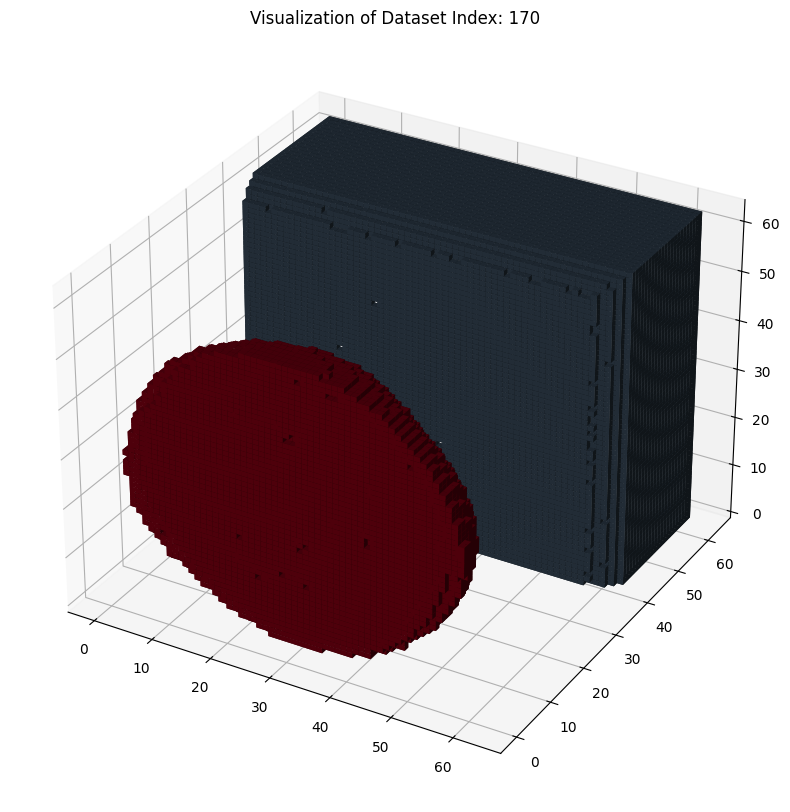

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 从刚刚生成的 492 个模型中随机选择一个进行验证
# dataset 维度为 [N, 64, 64, 64, 4]
test_idx = np.random.randint(0, len(dataset))
sample_voxel = dataset[test_idx]

# 分离颜色和占用信息
# 归一化颜色到 [0, 1]
colors = sample_voxel[..., :3].astype(np.float32) / 255.0
# 最后一层是 occupancy (255 表示存在)
occupancy = sample_voxel[..., 3] > 0

# 可视化
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# 绘制体素
ax.voxels(occupancy, facecolors=colors, edgecolor=None)

plt.title(f"Visualization of Dataset Index: {test_idx}")
plt.show()

In [ ]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.8 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1


In [ ]:
import open3d as o3d
import numpy as np

# 1. 获取占据状态的掩码和坐标
# occupancy 是在之前单元格中从 sample_voxel 提取的布尔数组
occupancy_mask = sample_voxel[..., 3] > 0
coords = np.argwhere(occupancy_mask)

# 2. 获取对应坐标的颜色并归一化
# 注意：colors 必须与 coords 的行数一致 (N, 3)
# Open3D 的 C++ 绑定强制要求 float64 类型
colors = sample_voxel[occupancy_mask][..., :3].astype(np.float64) / 255.0

# 3. 创建点云对象
pcd = o3d.geometry.PointCloud()

# 确保坐标也是 float64
pcd.points = o3d.utility.Vector3dVector(coords.astype(np.float64))
pcd.colors = o3d.utility.Vector3dVector(colors)

# 4. 交互式显示
print(f"正在通过 Open3D 展示模型索引: {test_idx}")
o3d.visualization.draw_plotly([pcd])

正在通过 Open3D 展示模型索引: 170


In [ ]:
# 根据当前展示的模型索引 test_idx 获取对应的 UID
current_uid = valid_uids[test_idx]

# 从说明字典中获取文字描述
current_description = chair_descriptions.get(current_uid, "暂无说明")

print(f"模型索引: {test_idx}")
print(f"模型 UID: {current_uid}")
print(f"模型说明:\n{current_description}")

模型索引: 170
模型 UID: 25f0b058cd2342fa9dfdf41c9df5fc82
模型说明:
A high-poly Velvet Bean Bag, perfect for interior renderings! I'm still a newbie when it comes to uploading to Sketchfab from Blender, so I couldn't figure out how to add here the bump mapping to give it that velvet look, but it is basically a Noise Texture plugged to the Normal socket of the Shader with a very big scale.


# token化体素

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VectorQuantizer(nn.Module):
    """
    向量量化层：将连续的特征映射为离散的 Codebook 索引 (Tokens)
    """
    def __init__(self, num_embeddings=512, embedding_dim=64, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        # 离散的 Codebook（词表），存储 512 个维度为 64 的向量
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, inputs):
        # inputs 预期维度: [B, C, D, H, W]
        # 转换为 [B, D, H, W, C] 以便计算通道维度的距离
        inputs = inputs.permute(0, 2, 3, 4, 1).contiguous()
        input_shape = inputs.shape

        # 展平为 [N, C] 格式
        flat_input = inputs.view(-1, self.embedding_dim)

        # 计算输入向量与 Codebook 中所有向量的欧式距离
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True)
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(flat_input, self.embedding.weight.t()))

        # 核心：找到最近的词表索引 (Token ID)
        encoding_indices = torch.argmin(distances, dim=1).view(input_shape[0], input_shape[1], input_shape[2], input_shape[3])

        # 根据索引提取量化后的向量 (用于训练)
        encodings = torch.zeros(flat_input.shape[0], self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices.view(-1, 1), 1)
        quantized = torch.matmul(encodings, self.embedding.weight).view(input_shape)

        # 转换回 [B, C, D, H, W]
        quantized = quantized.permute(0, 4, 1, 2, 3).contiguous()

        return quantized, encoding_indices

# ─── 使用示例 ───
if __name__ == "__main__":
    # 假设我们有一个提取出的特征图 (Batch=1, Dim=64, 空间大小 4x4x4)
    feature_map = torch.randn(1, 64, 4, 4, 4)

    quantizer = VectorQuantizer(num_embeddings=512, embedding_dim=64)
    _, tokens = quantizer(feature_map)

    print(f"输入特征维度: {feature_map.shape}")
    print(f"Token 化后的索引维度: {tokens.shape}")
    print(f"提取出的部分 Token ID: \n{tokens[0, 0, 0, :]}")

输入特征维度: torch.Size([1, 64, 4, 4, 4])
Token 化后的索引维度: torch.Size([1, 4, 4, 4])
提取出的部分 Token ID: 
tensor([239, 180, 441, 496])


In [ ]:
import torch
import numpy as np

# 1. 准备数据：将 RGB 和 Occupancy 拼接为 4 通道输入
# voxel_rgb: [64, 64, 64, 3], occupancy: [64, 64, 64]
# 转换为 [Channels, D, H, W] -> [4, 64, 64, 64]
rgb_tensor = torch.from_numpy(voxel_rgb).permute(3, 0, 1, 2).float() / 255.0
occ_tensor = torch.from_numpy(occupancy).unsqueeze(0).float()
input_voxel = torch.cat([rgb_tensor, occ_tensor], dim=0).unsqueeze(0) # 添加 Batch 维: [1, 4, 64, 64, 64]

# 2. 初始化 Quantizer 并映射维度
# 因为 VectorQuantizer 定义的 embedding_dim 是 64，而输入是 4，
# 我们需要一个简单的投影层将 4 通道转为 64 通道
projection = torch.nn.Conv3d(4, 64, kernel_size=1)
quantizer = VectorQuantizer(num_embeddings=512, embedding_dim=64)

# 3. 执行 Token 化
with torch.no_grad():
    features = projection(input_voxel)
    quantized_latents, tokens = quantizer(features)

print(f"输入体素维度: {input_voxel.shape}")
print(f"生成的 Token 矩阵维度: {tokens.shape} (对应空间 64x64x64)")
print(f"前 5 个非零 Token ID: {tokens[tokens > 0][:5].tolist()}")

输入体素维度: torch.Size([1, 4, 64, 64, 64])
生成的 Token 矩阵维度: torch.Size([1, 64, 64, 64]) (对应空间 64x64x64)
前 5 个非零 Token ID: [281, 281, 281, 281, 281]


In [ ]:
import torch
import torch.nn as nn

# 1. 定义一个简单的下采样编码器 (64^3 -> 8^3)
class SimpleEncoder(nn.Module):
    def __init__(self, in_channels=4, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(in_channels, 32, kernel_size=4, stride=2, padding=1), # 32^3
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=4, stride=2, padding=1),          # 16^3
            nn.ReLU(),
            nn.Conv3d(64, latent_dim, kernel_size=4, stride=2, padding=1),  # 8^3
            nn.ReLU()
        )
    def forward(self, x): return self.net(x)

# 2. 实例化并运行
encoder = SimpleEncoder(in_channels=4, latent_dim=64)
quantizer = VectorQuantizer(num_embeddings=512, embedding_dim=64)

with torch.no_grad():
    # input_voxel 维度为 [1, 4, 64, 64, 64]
    latent_features = encoder(input_voxel)
    _, tokens = quantizer(latent_features)

# 3. 展平为序列格式
flattened_tokens = tokens.view(-1)

print(f"下采样后的特征维度: {latent_features.shape}")
print(f"压缩后的 Token 矩阵维度: {tokens.shape}")
print(f"最终 Token 序列长度: {len(flattened_tokens)}")
print(f"前 20 个 Token 示例: {flattened_tokens[:20].tolist()}")

下采样后的特征维度: torch.Size([1, 64, 8, 8, 8])
压缩后的 Token 矩阵维度: torch.Size([1, 8, 8, 8])
最终 Token 序列长度: 512
前 20 个 Token 示例: [5, 139, 139, 139, 139, 139, 139, 416, 356, 328, 140, 140, 140, 140, 356, 268, 263, 215, 215, 215]


# 模型网络搭建

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VectorQuantizer(nn.Module):
    """
    向量量化层：将连续的特征映射为离散的 Codebook 索引
    """
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        # 离散的 Codebook（词表），每个 Token 对应一个连续向量
        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, inputs):
        # inputs 维度: [B, C, D, H, W] -> 转换为 [B, D, H, W, C]
        inputs = inputs.permute(0, 2, 3, 4, 1).contiguous()
        input_shape = inputs.shape

        # 展平以便计算距离: [B*D*H*W, C]
        flat_input = inputs.view(-1, self.embedding_dim)

        # 计算输入向量与 Codebook 中所有向量的欧式距离: (a-b)^2 = a^2 + b^2 - 2ab
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True)
                     + torch.sum(self.embedding.weight**2, dim=1)
                     - 2 * torch.matmul(flat_input, self.embedding.weight.t()))

        # 找到最近的 Embedding 索引 (Token ID)
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)

        # 将其转为 One-hot 编码并提取对应的 Embedding 向量
        encodings = torch.zeros(encoding_indices.shape[0], self.num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)
        quantized = torch.matmul(encodings, self.embedding.weight).view(input_shape)

        # 计算 VQ 损失
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self.commitment_cost * e_latent_loss

        # 梯度直通估计 (Straight-Through Estimator)
        quantized = inputs + (quantized - inputs).detach()

        # 转换回 [B, C, D, H, W] 并返回 Token 索引
        quantized = quantized.permute(0, 4, 1, 2, 3).contiguous()
        encoding_indices = encoding_indices.view(input_shape[0], input_shape[1], input_shape[2], input_shape[3])

        return quantized, loss, encoding_indices


class VoxelEncoder(nn.Module):
    """极简 3D CNN 编码器：将 32x32x32 降采样为 4x4x4"""
    def __init__(self, in_channels=4, latent_dim=64): # 假设输入是 RGBA 4通道
        super(VoxelEncoder, self).__init__()
        self.conv = nn.Sequential(
            # 32x32x32 -> 16x16x16
            nn.Conv3d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            # 16x16x16 -> 8x8x8
            nn.Conv3d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            # 8x8x8 -> 4x4x4
            nn.Conv3d(64, latent_dim, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(latent_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class VoxelDecoder(nn.Module):
    """极简 3D CNN 解码器：将 4x4x4 还原为 32x32x32"""
    def __init__(self, latent_dim=64, out_channels=4):
        super(VoxelDecoder, self).__init__()
        self.deconv = nn.Sequential(
            # 4x4x4 -> 8x8x8
            nn.ConvTranspose3d(latent_dim, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            # 8x8x8 -> 16x16x16
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            # 16x16x16 -> 32x32x32
            nn.ConvTranspose3d(32, out_channels, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        x = self.deconv(x)
        # 假设前3个通道是RGB（用Tanh限制在-1到1），最后一个通道是Occupancy（用Sigmoid表示概率）
        rgb = torch.tanh(x[:, :3, :, :, :])
        occupancy = torch.sigmoid(x[:, 3:, :, :, :])
        return torch.cat([rgb, occupancy], dim=1)


class VoxelVQVAE(nn.Module):
    """完整的 3D VQ-VAE 网络"""
    def __init__(self, in_channels=4, num_embeddings=512, embedding_dim=64):
        super(VoxelVQVAE, self).__init__()
        self.encoder = VoxelEncoder(in_channels, embedding_dim)
        self.quantizer = VectorQuantizer(num_embeddings, embedding_dim)
        self.decoder = VoxelDecoder(embedding_dim, in_channels)

    def forward(self, x):
        z = self.encoder(x)
        quantized, vq_loss, tokens = self.quantizer(z)
        x_recon = self.decoder(quantized)
        return x_recon, vq_loss, tokens


# ─── 单元测试 ───
if __name__ == "__main__":
    # 模拟输入：Batch_size=2, 4通道(RGBA), 分辨率 32x32x32
    mock_input = torch.randn(2, 4, 32, 32, 32)

    # 实例化模型：词表大小设为 512，Embedding 维度 64
    model = VoxelVQVAE(in_channels=4, num_embeddings=512, embedding_dim=64)

    x_recon, vq_loss, tokens = model(mock_input)

    print("===== 维度验证 =====")
    print(f"输入维度:      {mock_input.shape}")
    print(f"重构输出维度:   {x_recon.shape}")
    print(f"提取的 Token 形状 (4x4x4 空间): {tokens.shape}")
    print(f"第一个样本的前几个 Token ID: \n{tokens[0, 0, 0, :]}") # 查看局部的 Token ID
    print(f"VQ 损失值:     {vq_loss.item():.4f}")

===== 维度验证 =====
输入维度:      torch.Size([2, 4, 32, 32, 32])
重构输出维度:   torch.Size([2, 4, 32, 32, 32])
提取的 Token 形状 (4x4x4 空间): torch.Size([2, 4, 4, 4])
第一个样本的前几个 Token ID: 
tensor([421, 335, 138,  28])
VQ 损失值:     0.6218


In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. 准备数据加载器
# dataset 形状为 [492, 64, 64, 64, 4], 需转换为 [N, 4, 64, 64, 64] 并归一化
# 注意：由于内存限制，我们将 64^3 缩放回 32^3 以适配之前定义的极简模型架构
print("正在准备数据...")
x_train = torch.from_numpy(dataset).permute(0, 4, 1, 2, 3).float()
x_train[:, :3, ...] /= 255.0  # RGB 归一化
x_train[:, 3, ...] /= 255.0   # Occupancy 归一化

# 为了匹配 VoxelVQVAE 默认的 32^3 架构，进行下采样插值
x_train_32 = torch.nn.functional.interpolate(x_train, size=(32, 32, 32), mode='trilinear', align_corners=False)

train_loader = DataLoader(TensorDataset(x_train_32), batch_size=8, shuffle=True)

# 2. 初始化模型、优化器与损失函数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VoxelVQVAE(in_channels=4, num_embeddings=512, embedding_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
recon_loss_fn = torch.nn.MSELoss()

# 3. 训练一个 Epoch
model.train()
print(f"开始验证训练 (设备: {device})...")

total_loss = 0
for batch_idx, (x,) in enumerate(train_loader):
    x = x.to(device)
    optimizer.zero_grad()

    # 前向传播
    x_recon, vq_loss, _ = model(x)

    # 计算重构损失 (RGB + Occupancy)
    recon_loss = recon_loss_fn(x_recon, x)

    # 总损失
    loss = recon_loss + vq_loss

    # 反向传播
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

    if batch_idx % 10 == 0:
        print(f"Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f} (Recon: {recon_loss.item():.4f}, VQ: {vq_loss.item():.4f})")

print(f"\n训练验证完成！平均损失: {total_loss / len(train_loader):.4f}")

正在准备数据...
开始验证训练 (设备: cpu)...
Batch 0/62 | Loss: 0.7834 (Recon: 0.1498, VQ: 0.6335)
Batch 10/62 | Loss: 0.8005 (Recon: 0.0346, VQ: 0.7659)
Batch 20/62 | Loss: 0.7264 (Recon: 0.0216, VQ: 0.7048)
Batch 30/62 | Loss: 0.6600 (Recon: 0.0161, VQ: 0.6439)
Batch 40/62 | Loss: 0.6400 (Recon: 0.0175, VQ: 0.6225)
Batch 50/62 | Loss: 0.5754 (Recon: 0.0140, VQ: 0.5614)
Batch 60/62 | Loss: 0.5540 (Recon: 0.0169, VQ: 0.5371)

训练验证完成！平均损失: 0.6835


# 体素还原

还原后的体素维度: (64, 64, 64, 3)


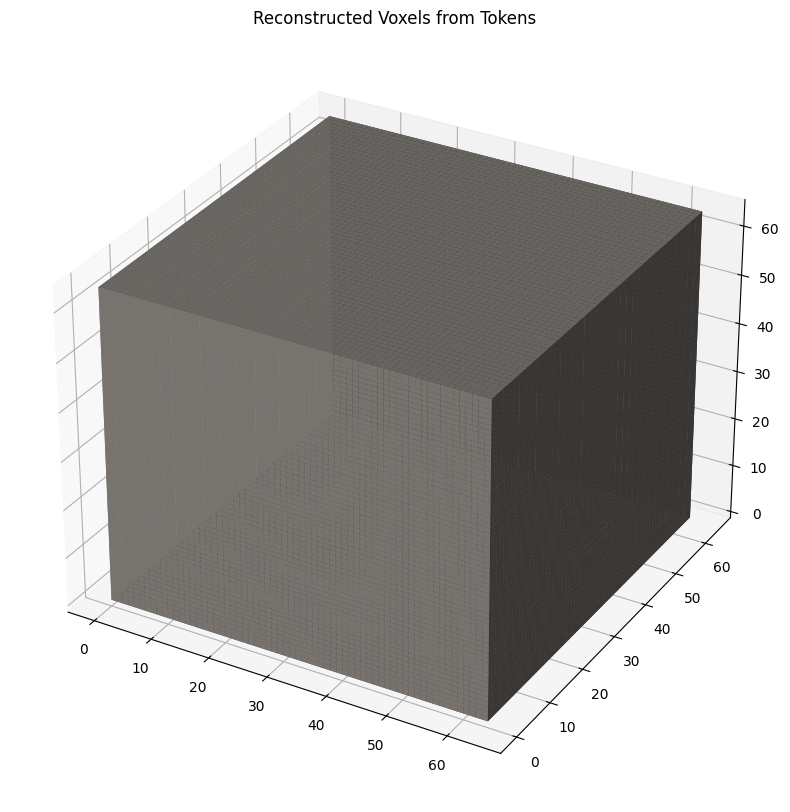

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 定义配套的解码器 (8^3 -> 64^3)
class SimpleDecoder(nn.Module):
    def __init__(self, latent_dim=64, out_channels=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose3d(latent_dim, 64, kernel_size=4, stride=2, padding=1), # 16^3
            nn.ReLU(),
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),          # 32^3
            nn.ReLU(),
            nn.ConvTranspose3d(32, out_channels, kernel_size=4, stride=2, padding=1) # 64^3
        )
    def forward(self, x):
        x = self.net(x)
        # 还原 RGB (Tanh -> [0, 1]) 和 Occupancy (Sigmoid)
        rgb = (torch.tanh(x[:, :3, :, :, :]) + 1) / 2.0
        occ = torch.sigmoid(x[:, 3:, :, :, :])
        return rgb, occ

# 2. 执行还原过程
decoder = SimpleDecoder(latent_dim=64, out_channels=4)

with torch.no_grad():
    # A. 从 Token ID 查找对应的 Embedding 向量
    # flattened_tokens 维度为 [512]
    embeddings = quantizer.embedding(flattened_tokens) # [512, 64]

    # B. 重塑回空间维度 [Batch, Channels, D, H, W] -> [1, 64, 8, 8, 8]
    latent_reshaped = embeddings.view(1, 8, 8, 8, 64).permute(0, 4, 1, 2, 3)

    # C. 通过解码器还原回体素
    recon_rgb, recon_occ = decoder(latent_reshaped)

# 3. 结果处理与可视化
# 去掉 Batch 维，并转回 Numpy
final_rgb = recon_rgb.squeeze(0).permute(1, 2, 3, 0).numpy()
final_occ = (recon_occ.squeeze() > 0.5).numpy() # 阈值化处理

print(f"还原后的体素维度: {final_rgb.shape}")

# 可视化
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.voxels(final_occ, facecolors=final_rgb, edgecolor=None)
plt.title("Reconstructed Voxels from Tokens")
plt.show()